# CardioGuard: Explainable Heart Disease Risk Classifier
### UX25CS635A - Supervised Machine Learning (Classification) - Mini Project


---

## 1. Problem Statement

Heart disease is one of the leading causes of death worldwide, and early risk screening can help
doctors intervene sooner. Clinicians currently judge risk from a combination of measurements
(age, cholesterol, blood pressure, ECG results, etc.). This project builds a **supervised binary
classification model** that predicts whether a patient is likely to have heart disease (`1`) or not
(`0`) from 13 standard clinical features, wraps it in a **rigorous validation pipeline**, adds
**explainability**, and ships an **interactive clinical dashboard**.




## 2. Setup

In [1]:
# Imports (run this cell first, every time you open the notebook)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score, GridSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 3. Load the Data




In [2]:
CSV_DATA = """age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
44,1,1,120,263,0,1,173,0,0,2,0,3,1
52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
57,1,2,150,168,0,1,174,0,1.6,2,0,2,1
54,1,0,140,239,0,1,160,0,1.2,2,0,2,1
48,0,2,130,275,0,1,139,0,0.2,2,0,2,1
49,1,1,130,266,0,1,171,0,0.6,2,0,2,1
64,1,3,110,211,0,0,144,1,1.8,1,0,2,1
58,0,3,150,283,1,0,162,0,1,2,0,2,1
50,0,2,120,219,0,1,158,0,1.6,1,0,2,1
58,0,2,120,340,0,1,172,0,0,2,0,2,1
66,0,3,150,226,0,1,114,0,2.6,0,0,2,1
43,1,0,150,247,0,1,171,0,1.5,2,0,2,1
69,0,3,140,239,0,1,151,0,1.8,2,2,2,1
59,1,0,135,234,0,1,161,0,0.5,1,0,3,1
44,1,2,130,233,0,1,179,1,0.4,2,0,2,1
42,1,0,140,226,0,1,178,0,0,2,0,2,1
61,1,2,150,243,1,1,137,1,1,1,0,2,1
40,1,3,140,199,0,1,178,1,1.4,2,0,3,1
71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
59,1,2,150,212,1,1,157,0,1.6,2,0,2,1
51,1,2,110,175,0,1,123,0,0.6,2,0,2,1
65,0,2,140,417,1,0,157,0,0.8,2,1,2,1
53,1,2,130,197,1,0,152,0,1.2,0,0,2,1
41,0,1,105,198,0,1,168,0,0,2,1,2,1
65,1,0,120,177,0,1,140,0,0.4,2,0,3,1
44,1,1,130,219,0,0,188,0,0,2,0,2,1
54,1,2,125,273,0,0,152,0,0.5,0,1,2,1
51,1,3,125,213,0,0,125,1,1.4,2,1,2,1
46,0,2,142,177,0,0,160,1,1.4,0,0,2,1
54,0,2,135,304,1,1,170,0,0,2,0,2,1
54,1,2,150,232,0,0,165,0,1.6,2,0,3,1
65,0,2,155,269,0,1,148,0,0.8,2,0,2,1
65,0,2,160,360,0,0,151,0,0.8,2,0,2,1
51,0,2,140,308,0,0,142,0,1.5,2,1,2,1
48,1,1,130,245,0,0,180,0,0.2,1,0,2,1
45,1,0,104,208,0,0,148,1,3,1,0,2,1
53,0,0,130,264,0,0,143,0,0.4,1,0,2,1
39,1,2,140,321,0,0,182,0,0,2,0,2,1
52,1,1,120,325,0,1,172,0,0.2,2,0,2,1
44,1,2,140,235,0,0,180,0,0,2,0,2,1
47,1,2,138,257,0,0,156,0,0,2,0,2,1
53,0,2,128,216,0,0,115,0,0,2,0,0,1
53,0,0,138,234,0,0,160,0,0,2,0,2,1
51,0,2,130,256,0,0,149,0,0.5,2,0,2,1
66,1,0,120,302,0,0,151,0,0.4,1,0,2,1
62,1,2,130,231,0,1,146,0,1.8,1,3,3,1
44,0,2,108,141,0,1,175,0,0.6,1,0,2,1
63,0,2,135,252,0,0,172,0,0,2,0,2,1
52,1,1,134,201,0,1,158,0,0.8,2,1,2,1
48,1,0,122,222,0,0,186,0,0,2,0,2,1
45,1,0,115,260,0,0,185,0,0,2,0,2,1
34,1,3,118,182,0,0,174,0,0,2,0,2,1
57,0,0,128,303,0,0,159,0,0,2,1,2,1
71,0,2,110,265,1,0,130,0,0,2,1,2,1
54,1,1,108,309,0,1,156,0,0,2,0,3,1
52,1,3,118,186,0,0,190,0,0,1,0,1,1
41,1,1,135,203,0,1,132,0,0,1,0,1,1
58,1,2,140,211,1,0,165,0,0,2,0,2,1
35,0,0,138,183,0,1,182,0,1.4,2,0,2,1
51,1,2,100,222,0,1,143,1,1.2,1,0,2,1
45,0,1,130,234,0,0,175,0,0.6,1,0,2,1
44,1,1,120,220,0,1,170,0,0,2,0,2,1
62,0,0,124,209,0,1,163,0,0,2,0,2,1
54,1,2,120,258,0,0,147,0,0.4,1,0,3,1
51,1,2,94,227,0,1,154,1,0,2,1,3,1
29,1,1,130,204,0,0,202,0,0,2,0,2,1
51,1,0,140,261,0,0,186,1,0,2,0,2,1
43,0,2,122,213,0,1,165,0,0.2,1,0,2,1
55,0,1,135,250,0,0,161,0,1.4,1,0,2,1
51,1,2,125,245,1,0,166,0,2.4,1,0,2,1
59,1,1,140,221,0,1,164,1,0,2,0,2,1
52,1,1,128,205,1,1,184,0,0,2,0,2,1
58,1,2,105,240,0,0,154,1,0.6,1,0,3,1
41,1,2,112,250,0,1,179,0,0,2,0,2,1
45,1,1,128,308,0,0,170,0,0,2,0,2,1
60,0,2,102,318,0,1,160,0,0,2,1,2,1
52,1,3,152,298,1,1,178,0,1.2,1,0,3,1
42,0,0,102,265,0,0,122,0,0.6,1,0,2,1
67,0,2,115,564,0,0,160,0,1.6,1,0,3,1
68,1,2,118,277,0,1,151,0,1,2,1,3,1
46,1,1,101,197,1,1,156,0,0,2,0,3,1
54,0,2,110,214,0,1,158,0,1.6,1,0,2,1
58,0,0,100,248,0,0,122,0,1,1,0,2,1
48,1,2,124,255,1,1,175,0,0,2,2,2,1
57,1,0,132,207,0,1,168,1,0,2,0,3,1
52,1,2,138,223,0,1,169,0,0,2,4,2,1
54,0,1,132,288,1,0,159,1,0,2,1,2,1
45,0,1,112,160,0,1,138,0,0,1,0,2,1
53,1,0,142,226,0,0,111,1,0,2,0,3,1
62,0,0,140,394,0,0,157,0,1.2,1,0,2,1
52,1,0,108,233,1,1,147,0,0.1,2,3,3,1
43,1,2,130,315,0,1,162,0,1.9,2,1,2,1
53,1,2,130,246,1,0,173,0,0,2,3,2,1
42,1,3,148,244,0,0,178,0,0.8,2,2,2,1
59,1,3,178,270,0,0,145,0,4.2,0,0,3,1
63,0,1,140,195,0,1,179,0,0,2,2,2,1
42,1,2,120,240,1,1,194,0,0.8,0,0,3,1
50,1,2,129,196,0,1,163,0,0,2,0,2,1
68,0,2,120,211,0,0,115,0,1.5,1,0,2,1
69,1,3,160,234,1,0,131,0,0.1,1,1,2,1
45,0,0,138,236,0,0,152,1,0.2,1,0,2,1
50,0,1,120,244,0,1,162,0,1.1,2,0,2,1
50,0,0,110,254,0,0,159,0,0,2,0,2,1
64,0,0,180,325,0,1,154,1,0,2,0,2,1
57,1,2,150,126,1,1,173,0,0.2,2,1,3,1
64,0,2,140,313,0,1,133,0,0.2,2,0,3,1
43,1,0,110,211,0,1,161,0,0,2,0,3,1
55,1,1,130,262,0,1,155,0,0,2,0,2,1
37,0,2,120,215,0,1,170,0,0,2,0,2,1
41,1,2,130,214,0,0,168,0,2,1,0,2,1
56,1,3,120,193,0,0,162,0,1.9,1,0,3,1
46,0,1,105,204,0,1,172,0,0,2,0,2,1
46,0,0,138,243,0,0,152,1,0,1,0,2,1
64,0,0,130,303,0,1,122,0,2,1,2,2,1
59,1,0,138,271,0,0,182,0,0,2,0,2,1
41,0,2,112,268,0,0,172,1,0,2,0,2,1
54,0,2,108,267,0,0,167,0,0,2,0,2,1
39,0,2,94,199,0,1,179,0,0,2,0,2,1
34,0,1,118,210,0,1,192,0,0.7,2,0,2,1
47,1,0,112,204,0,1,143,0,0.1,2,0,2,1
67,0,2,152,277,0,1,172,0,0,2,1,2,1
52,0,2,136,196,0,0,169,0,0.1,1,0,2,1
74,0,1,120,269,0,0,121,1,0.2,2,1,2,1
54,0,2,160,201,0,1,163,0,0,2,1,2,1
49,0,1,134,271,0,1,162,0,0,1,0,2,1
42,1,1,120,295,0,1,162,0,0,2,0,2,1
41,1,1,110,235,0,1,153,0,0,2,0,2,1
41,0,1,126,306,0,1,163,0,0,2,0,2,1
49,0,0,130,269,0,1,163,0,0,2,0,2,1
60,0,2,120,178,1,1,96,0,0,2,0,2,1
62,1,1,128,208,1,0,140,0,0,2,0,2,1
57,1,0,110,201,0,1,126,1,1.5,1,0,1,1
64,1,0,128,263,0,1,105,1,0.2,1,1,3,1
51,0,2,120,295,0,0,157,0,0.6,2,0,2,1
43,1,0,115,303,0,1,181,0,1.2,1,0,2,1
42,0,2,120,209,0,1,173,0,0,1,0,2,1
67,0,0,106,223,0,1,142,0,0.3,2,2,2,1
76,0,2,140,197,0,2,116,0,1.1,1,0,2,1
70,1,1,156,245,0,0,143,0,0,2,0,2,1
44,0,2,118,242,0,1,149,0,0.3,1,1,2,1
60,0,3,150,240,0,1,171,0,0.9,2,0,2,1
44,1,2,120,226,0,1,169,0,0,2,0,2,1
42,1,2,130,180,0,1,150,0,0,2,0,2,1
66,1,0,160,228,0,0,138,0,2.3,2,0,1,1
71,0,0,112,149,0,1,125,0,1.6,1,0,2,1
64,1,3,170,227,0,0,155,0,0.6,1,0,3,1
66,0,2,146,278,0,0,152,0,0,1,1,2,1
39,0,2,138,220,0,1,152,0,0,1,0,2,1
58,0,0,130,197,0,1,131,0,0.6,1,0,2,1
47,1,2,130,253,0,1,179,0,0,2,0,2,1
35,1,1,122,192,0,1,174,0,0,2,0,2,1
58,1,1,125,220,0,1,144,0,0.4,1,4,3,1
56,1,1,130,221,0,0,163,0,0,2,0,3,1
56,1,1,120,240,0,1,169,0,0,0,0,2,1
55,0,1,132,342,0,1,166,0,1.2,2,0,2,1
41,1,1,120,157,0,1,182,0,0,2,0,2,1
38,1,2,138,175,0,1,173,0,0,2,4,2,1
38,1,2,138,175,0,1,173,0,0,2,4,2,1
67,1,0,160,286,0,0,108,1,1.5,1,3,2,0
67,1,0,120,229,0,0,129,1,2.6,1,2,3,0
62,0,0,140,268,0,0,160,0,3.6,0,2,2,0
63,1,0,130,254,0,0,147,0,1.4,1,1,3,0
53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
56,1,2,130,256,1,0,142,1,0.6,1,1,1,0
48,1,1,110,229,0,1,168,0,1,0,0,3,0
58,1,1,120,284,0,0,160,0,1.8,1,0,2,0
58,1,2,132,224,0,0,173,0,3.2,2,2,3,0
60,1,0,130,206,0,0,132,1,2.4,1,2,3,0
40,1,0,110,167,0,0,114,1,2,1,0,3,0
60,1,0,117,230,1,1,160,1,1.4,2,2,3,0
64,1,2,140,335,0,1,158,0,0,2,0,2,0
43,1,0,120,177,0,0,120,1,2.5,1,0,3,0
57,1,0,150,276,0,0,112,1,0.6,1,1,1,0
55,1,0,132,353,0,1,132,1,1.2,1,1,3,0
65,0,0,150,225,0,0,114,0,1,1,3,3,0
61,0,0,130,330,0,0,169,0,0,2,0,2,0
58,1,2,112,230,0,0,165,0,2.5,1,1,3,0
50,1,0,150,243,0,0,128,0,2.6,1,0,3,0
44,1,0,112,290,0,0,153,0,0,2,1,2,0
60,1,0,130,253,0,1,144,1,1.4,2,1,3,0
54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
50,1,2,140,233,0,1,163,0,0.6,1,1,3,0
41,1,0,110,172,0,0,158,0,0,2,0,3,0
51,0,0,130,305,0,1,142,1,1.2,1,0,3,0
58,1,0,128,216,0,0,131,1,2.2,1,3,3,0
54,1,0,120,188,0,1,113,0,1.4,1,1,3,0
60,1,0,145,282,0,0,142,1,2.8,1,2,3,0
60,1,2,140,185,0,0,155,0,3,1,0,2,0
59,1,0,170,326,0,0,140,1,3.4,0,0,3,0
46,1,2,150,231,0,1,147,0,3.6,1,0,2,0
67,1,0,125,254,1,1,163,0,0.2,1,2,3,0
62,1,0,120,267,0,1,99,1,1.8,1,2,3,0
65,1,0,110,248,0,0,158,0,0.6,2,2,1,0
44,1,0,110,197,0,0,177,0,0,2,1,2,0
60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
58,1,0,150,270,0,0,111,1,0.8,2,0,3,0
68,1,2,180,274,1,0,150,1,1.6,1,0,3,0
62,0,0,160,164,0,0,145,0,6.2,0,3,3,0
52,1,0,128,255,0,1,161,1,0,2,1,3,0
59,1,0,110,239,0,0,142,1,1.2,1,1,3,0
60,0,0,150,258,0,0,157,0,2.6,1,2,3,0
49,1,2,120,188,0,1,139,0,2,1,3,3,0
59,1,0,140,177,0,1,162,1,0,2,1,3,0
57,1,2,128,229,0,0,150,0,0.4,1,1,3,0
61,1,0,120,260,0,1,140,1,3.6,1,1,3,0
39,1,0,118,219,0,1,140,0,1.2,1,0,3,0
61,0,0,145,307,0,0,146,1,1,1,0,3,0
56,1,0,125,249,1,0,144,1,1.2,1,1,2,0
43,0,0,132,341,1,0,136,1,3,1,0,3,0
62,0,2,130,263,0,1,97,0,1.2,1,1,3,0
63,1,0,130,330,1,0,132,1,1.8,2,3,3,0
65,1,0,135,254,0,0,127,0,2.8,1,1,3,0
48,1,0,130,256,1,0,150,1,0,2,2,3,0
63,0,0,150,407,0,0,154,0,4,1,3,3,0
55,1,0,140,217,0,1,111,1,5.6,0,0,3,0
65,1,3,138,282,1,0,174,0,1.4,1,1,2,0
56,0,0,200,288,1,0,133,1,4,0,2,3,0
54,1,0,110,239,0,1,126,1,2.8,1,1,3,0
70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
62,1,1,120,281,0,0,103,0,1.4,1,1,3,0
35,1,0,120,198,0,1,130,1,1.6,1,0,3,0
59,1,3,170,288,0,0,159,0,0.2,1,0,3,0
64,1,2,125,309,0,1,131,1,1.8,1,0,3,0
47,1,2,108,243,0,1,152,0,0,2,0,2,0
57,1,0,165,289,1,0,124,0,1,1,3,3,0
55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
64,1,0,120,246,0,0,96,1,2.2,0,1,2,0
70,1,0,130,322,0,0,109,0,2.4,1,3,2,0
51,1,0,140,299,0,1,173,1,1.6,2,0,3,0
58,1,0,125,300,0,0,171,0,0,2,2,3,0
60,1,0,140,293,0,0,170,0,1.2,1,2,3,0
77,1,0,125,304,0,0,162,1,0,2,3,2,0
35,1,0,126,282,0,0,156,1,0,2,0,3,0
70,1,2,160,269,0,1,112,1,2.9,1,1,3,0
59,0,0,174,249,0,1,143,1,0,1,0,2,0
64,1,0,145,212,0,0,132,0,2,1,2,1,0
57,1,0,152,274,0,1,88,1,1.2,1,1,3,0
56,1,0,132,184,0,0,105,1,2.1,1,1,1,0
48,1,0,124,274,0,0,166,0,0.5,1,0,3,0
56,0,0,134,409,0,0,150,1,1.9,1,2,3,0
66,1,1,160,246,0,1,120,1,0,1,3,1,0
54,1,1,192,283,0,0,195,0,0,2,1,3,0
69,1,2,140,254,0,0,146,0,2,1,3,3,0
51,1,0,140,298,0,1,122,1,4.2,1,3,3,0
43,1,0,132,247,1,0,143,1,0.1,1,4,3,0
62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
67,1,0,100,299,0,0,125,1,0.9,1,2,2,0
59,1,3,160,273,0,0,125,0,0,2,0,2,0
45,1,0,142,309,0,0,147,1,0,1,3,3,0
58,1,0,128,259,0,0,130,1,3,1,2,3,0
50,1,0,144,200,0,0,126,1,0.9,1,0,3,0
62,0,0,150,244,0,1,154,1,1.4,1,0,2,0
38,1,3,120,231,0,1,182,1,3.8,1,0,3,0
66,0,0,178,228,1,1,165,1,1,1,2,3,0
52,1,0,112,230,0,1,160,0,0,2,1,2,0
53,1,0,123,282,0,1,95,1,2,1,2,3,0
63,0,0,108,269,0,1,169,1,1.8,1,2,2,0
54,1,0,110,206,0,0,108,1,0,1,1,2,0
66,1,0,112,212,0,0,132,1,0.1,2,1,2,0
55,0,0,180,327,0,2,117,1,3.4,1,0,2,0
49,1,2,118,149,0,0,126,0,0.8,2,3,2,0
54,1,0,122,286,0,0,116,1,3.2,1,2,2,0
56,1,0,130,283,1,0,103,1,1.6,0,0,3,0
46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
61,1,3,134,234,0,1,145,0,2.6,1,2,2,0
67,1,0,120,237,0,1,71,0,1,1,0,2,0
58,1,0,100,234,0,1,156,0,0.1,2,1,3,0
47,1,0,110,275,0,0,118,1,1,1,1,2,0
52,1,0,125,212,0,1,168,0,1,2,2,3,0
58,1,0,146,218,0,1,105,0,2,1,1,3,0
57,1,1,124,261,0,1,141,0,0.3,2,0,3,0
58,0,1,136,319,1,0,152,0,0,2,2,2,0
61,1,0,138,166,0,0,125,1,3.6,1,1,2,0
42,1,0,136,315,0,1,125,1,1.8,1,0,1,0
52,1,0,128,204,1,1,156,1,1,1,0,0,0
59,1,2,126,218,1,1,134,0,2.2,1,1,1,0
40,1,0,152,223,0,1,181,0,0,2,0,3,0
61,1,0,140,207,0,0,138,1,1.9,2,1,3,0
46,1,0,140,311,0,1,120,1,1.8,1,2,3,0
59,1,3,134,204,0,1,162,0,0.8,2,2,2,0
57,1,1,154,232,0,0,164,0,0,2,1,2,0
57,1,0,110,335,0,1,143,1,3,1,1,3,0
55,0,0,128,205,0,2,130,1,2,1,1,3,0
61,1,0,148,203,0,1,161,0,0,2,1,3,0
58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
58,0,0,170,225,1,0,146,1,2.8,1,2,1,0
67,1,2,152,212,0,0,150,0,0.8,1,0,3,0
44,1,0,120,169,0,1,144,1,2.8,0,0,1,0
63,1,0,140,187,0,0,144,1,4,2,2,3,0
63,0,0,124,197,0,1,136,1,0,1,0,2,0
59,1,0,164,176,1,0,90,0,1,1,2,1,0
57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
57,0,1,130,236,0,0,174,0,0,1,1,2,0"""

df_raw = pd.read_csv(StringIO(CSV_DATA))
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 4. Data Quality Checks & Cleaning

Always inspect and clean data *before* modelling: missing values, duplicate records, obviously invalid values, and class balance.

In [3]:
print("Missing values per column:")
print(df_raw.isnull().sum())

n_dupes = df_raw.duplicated().sum()
print(f"\nExact duplicate rows: {n_dupes}")

# Drop exact duplicate patient records (data leakage risk if the same
# patient ends up in both train and test)
df = df_raw.drop_duplicates().reset_index(drop=True)
print("Shape after de-duplication:", df.shape)

print("\nTarget class balance:")
print(df['target'].value_counts())
print((df['target'].value_counts(normalize=True) * 100).round(1).astype(str) + ' %')


Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Exact duplicate rows: 1
Shape after de-duplication: (302, 14)

Target class balance:
target
1    164
0    138
Name: count, dtype: int64
target
1    54.3 %
0    45.7 %
Name: proportion, dtype: str


## 5. Exploratory Data Analysis (EDA)

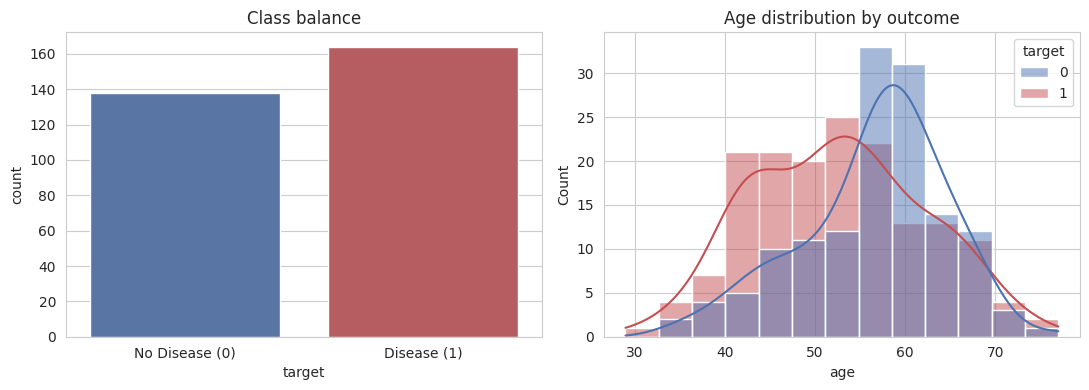

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='target', data=df, ax=ax[0], hue='target', palette=['#4C72B0', '#C44E52'], legend=False)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(['No Disease (0)', 'Disease (1)'])
ax[0].set_title('Class balance')

sns.histplot(data=df, x='age', hue='target', kde=True, ax=ax[1], palette=['#4C72B0', '#C44E52'])
ax[1].set_title('Age distribution by outcome')
plt.tight_layout()
plt.show()


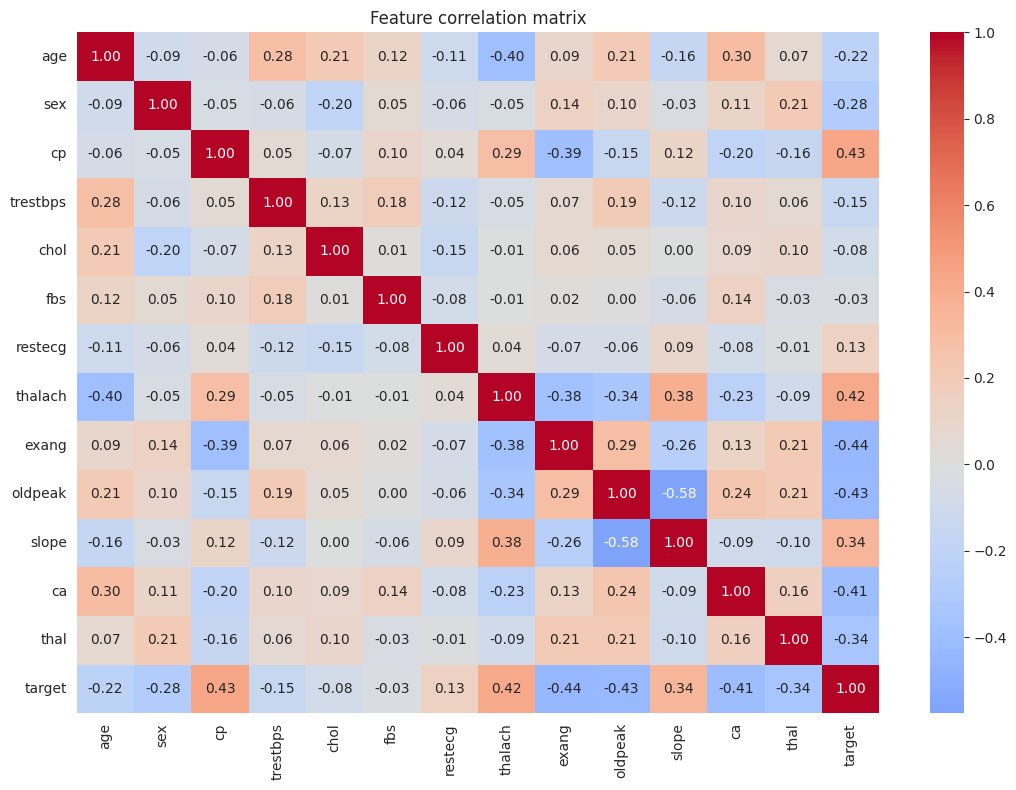

Features most correlated with target:
exang      0.435601
cp         0.432080
oldpeak    0.429146
thalach    0.419955
ca         0.408992
Name: target, dtype: float64


In [5]:
plt.figure(figsize=(11, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()

print("Features most correlated with target:")
print(corr['target'].abs().sort_values(ascending=False)[1:6])


## 6. Train / Test Split & Preprocessing Pipeline


In [6]:
X = df.drop(columns=['target'])
y = df['target']

numeric_features  = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
binary_features   = ['sex', 'fbs', 'exang']
nominal_features  = ['cp', 'restecg', 'slope', 'thal']

preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('bin', 'passthrough', binary_features),
    ('nom', OneHotEncoder(drop='first', handle_unknown='ignore'), nominal_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


Train size: (241, 13)  Test size: (61, 13)
Train class balance:
 target
1    0.544
0    0.456
Name: proportion, dtype: float64
Test class balance:
 target
1    0.541
0    0.459
Name: proportion, dtype: float64


## 7. Baseline Models with Hyperparameter Tuning

In [7]:
candidate_grids = {
    "Logistic Regression": (
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {'clf__C': [0.01, 0.1, 1, 10]}
    ),
    "K-Nearest Neighbors": (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [5, 7, 9, 11], 'clf__weights': ['uniform', 'distance']}
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=RANDOM_STATE),
        {'clf__max_depth': [3, 4, 5, 6], 'clf__min_samples_leaf': [1, 3, 5]}
    ),
    "Random Forest": (
        RandomForestClassifier(random_state=RANDOM_STATE),
        {'clf__n_estimators': [200, 400], 'clf__max_depth': [4, 6, None], 'clf__min_samples_leaf': [1, 2, 4]}
    ),
    "SVM (RBF)": (
        SVC(probability=True, random_state=RANDOM_STATE),
        {'clf__C': [0.1, 1, 10], 'clf__gamma': ['scale', 'auto']}
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {'clf__n_estimators': [100, 200], 'clf__learning_rate': [0.03, 0.1], 'clf__max_depth': [2, 3]}
    ),
}

best_estimators = {}
rows = []

for name, (estimator, grid) in candidate_grids.items():
    pipe = Pipeline([('prep', preprocess), ('clf', estimator)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_estimators[name] = gs.best_estimator_

    y_pred = gs.predict(X_test)
    y_prob = gs.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Best params": gs.best_params_,
        "CV ROC-AUC": gs.best_score_,
        "Test Accuracy": accuracy_score(y_test, y_pred),
        "Test Precision": precision_score(y_test, y_pred),
        "Test Recall": recall_score(y_test, y_pred),
        "Test F1": f1_score(y_test, y_pred),
        "Test ROC-AUC": roc_auc_score(y_test, y_prob),
    })
    print(f"{name:22s} tuned. CV ROC-AUC = {gs.best_score_:.3f}  | best params: {gs.best_params_}")

results_df = pd.DataFrame(rows).sort_values("CV ROC-AUC", ascending=False).reset_index(drop=True)
results_df.round(3)


Logistic Regression    tuned. CV ROC-AUC = 0.896  | best params: {'clf__C': 1}


K-Nearest Neighbors    tuned. CV ROC-AUC = 0.889  | best params: {'clf__n_neighbors': 7, 'clf__weights': 'distance'}


Decision Tree          tuned. CV ROC-AUC = 0.826  | best params: {'clf__max_depth': 4, 'clf__min_samples_leaf': 5}


Random Forest          tuned. CV ROC-AUC = 0.894  | best params: {'clf__max_depth': None, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 400}


SVM (RBF)              tuned. CV ROC-AUC = 0.883  | best params: {'clf__C': 1, 'clf__gamma': 'auto'}


Gradient Boosting      tuned. CV ROC-AUC = 0.890  | best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 2, 'clf__n_estimators': 100}


,Model,Best params,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,{'clf__C': 1},0.896,0.787,0.778,0.848,0.812,0.872
1,Random Forest,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.894,0.754,0.750,0.818,0.783,0.886
2,Gradient Boosting,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.890,0.787,0.778,0.848,0.812,0.874
3,K-Nearest Neighbors,"{'clf__n_neighbors': 7, 'clf__weights': 'dista...",0.889,0.803,0.800,0.848,0.824,0.892
4,SVM (RBF),"{'clf__C': 1, 'clf__gamma': 'auto'}",0.883,0.836,0.811,0.909,0.857,0.918
5,Decision Tree,"{'clf__max_depth': 4, 'clf__min_samples_leaf': 5}",0.826,0.721,0.690,0.879,0.773,0.708


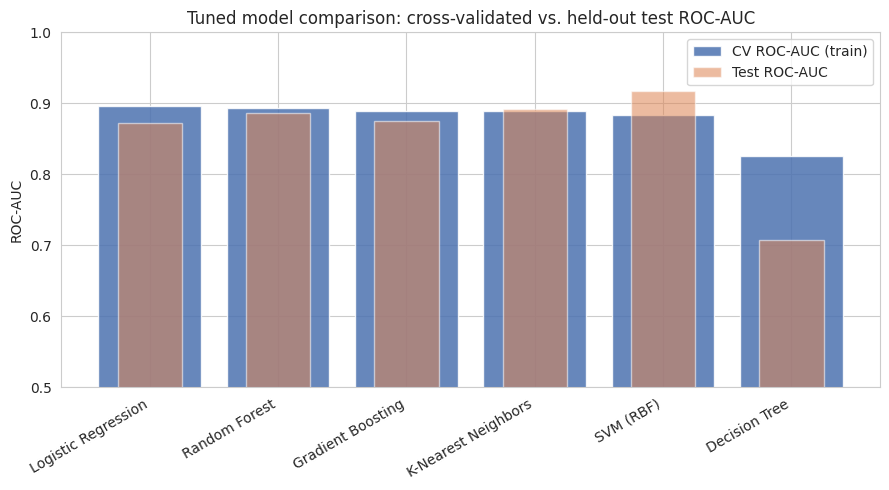

In [8]:
plt.figure(figsize=(9, 5))
plt.bar(results_df['Model'], results_df['CV ROC-AUC'], color='#4C72B0', alpha=0.85, label='CV ROC-AUC (train)')
plt.bar(results_df['Model'], results_df['Test ROC-AUC'], color='#DD8452', alpha=0.55, width=0.5, label='Test ROC-AUC')
plt.xticks(rotation=30, ha='right')
plt.ylabel("ROC-AUC")
plt.ylim(0.5, 1.0)
plt.legend()
plt.title("Tuned model comparison: cross-validated vs. held-out test ROC-AUC")
plt.tight_layout()
plt.show()


## 8. Novelty #1 - Tuned Stacking Ensemble

In [9]:
def make_stack(estimator_names):
    ests = [(n.split()[0].lower() + str(i), best_estimators[n].named_steps['clf'])
            for i, n in enumerate(estimator_names)]
    return Pipeline([
        ('prep', preprocess),
        ('clf', StackingClassifier(estimators=ests,
                                    final_estimator=LogisticRegression(max_iter=2000),
                                    cv=5, n_jobs=-1))
    ])

candidate_combos = {
    "Top-3 by CV ROC-AUC": results_df['Model'].head(3).tolist(),
    "Top-4 by CV ROC-AUC": results_df['Model'].head(4).tolist(),
    "All 6 models":        results_df['Model'].tolist(),
}

combo_scores = {}
for combo_name, model_names in candidate_combos.items():
    stack_pipe = make_stack(model_names)
    scores = cross_val_score(stack_pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    combo_scores[combo_name] = (scores.mean(), scores.std(), model_names)
    print(f"{combo_name:22s} ({', '.join(model_names)}): CV ROC-AUC = {scores.mean():.3f} (+/- {scores.std():.3f})")

best_combo_name = max(combo_scores, key=lambda k: combo_scores[k][0])
best_combo_models = combo_scores[best_combo_name][2]
print(f"\nSelected combination: {best_combo_name}  ->  {best_combo_models}")


Top-3 by CV ROC-AUC    (Logistic Regression, Random Forest, Gradient Boosting): CV ROC-AUC = 0.898 (+/- 0.039)


Top-4 by CV ROC-AUC    (Logistic Regression, Random Forest, Gradient Boosting, K-Nearest Neighbors): CV ROC-AUC = 0.897 (+/- 0.042)


All 6 models           (Logistic Regression, Random Forest, Gradient Boosting, K-Nearest Neighbors, SVM (RBF), Decision Tree): CV ROC-AUC = 0.897 (+/- 0.040)

Selected combination: Top-3 by CV ROC-AUC  ->  ['Logistic Regression', 'Random Forest', 'Gradient Boosting']


In [10]:
FINAL_NAME = f"Stacking Ensemble ({best_combo_name})"
FINAL_MODEL = make_stack(best_combo_models)
FINAL_MODEL.fit(X_train, y_train)

y_pred_stack = FINAL_MODEL.predict(X_test)
y_prob_stack = FINAL_MODEL.predict_proba(X_test)[:, 1]

stack_scores = {
    "Model": FINAL_NAME,
    "Best params": "(base learners tuned individually in Section 7)",
    "CV ROC-AUC": combo_scores[best_combo_name][0],
    "Test Accuracy": accuracy_score(y_test, y_pred_stack),
    "Test Precision": precision_score(y_test, y_pred_stack),
    "Test Recall": recall_score(y_test, y_pred_stack),
    "Test F1": f1_score(y_test, y_pred_stack),
    "Test ROC-AUC": roc_auc_score(y_test, y_prob_stack),
}

final_comparison = pd.concat([results_df, pd.DataFrame([stack_scores])], ignore_index=True)
final_comparison.round(3)


,Model,Best params,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,{'clf__C': 1},0.896,0.787,0.778,0.848,0.812,0.872
1,Random Forest,"{'clf__max_depth': None, 'clf__min_samples_lea...",0.894,0.754,0.750,0.818,0.783,0.886
2,Gradient Boosting,"{'clf__learning_rate': 0.1, 'clf__max_depth': ...",0.890,0.787,0.778,0.848,0.812,0.874
3,K-Nearest Neighbors,"{'clf__n_neighbors': 7, 'clf__weights': 'dista...",0.889,0.803,0.800,0.848,0.824,0.892
4,SVM (RBF),"{'clf__C': 1, 'clf__gamma': 'auto'}",0.883,0.836,0.811,0.909,0.857,0.918
5,Decision Tree,"{'clf__max_depth': 4, 'clf__min_samples_leaf': 5}",0.826,0.721,0.690,0.879,0.773,0.708
6,Stacking Ensemble (Top-3 by CV ROC-AUC),(base learners tuned individually in Section 7),0.898,0.770,0.757,0.848,0.800,0.881


### 8b. Final Validation of the Deployed Model

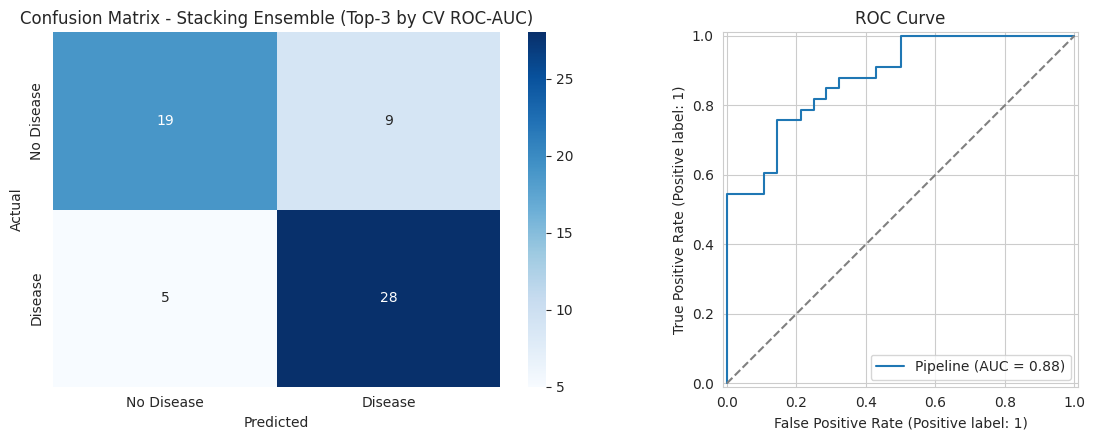

              precision    recall  f1-score   support

  No Disease       0.79      0.68      0.73        28
     Disease       0.76      0.85      0.80        33

    accuracy                           0.77        61
   macro avg       0.77      0.76      0.77        61
weighted avg       0.77      0.77      0.77        61



In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

cm = confusion_matrix(y_test, y_pred_stack)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'], ax=ax[0])
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('Actual')
ax[0].set_title(f'Confusion Matrix - {FINAL_NAME}')

RocCurveDisplay.from_estimator(FINAL_MODEL, X_test, y_test, ax=ax[1])
ax[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
ax[1].set_title('ROC Curve')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_stack, target_names=['No Disease', 'Disease']))


### 8c. Learning Curve

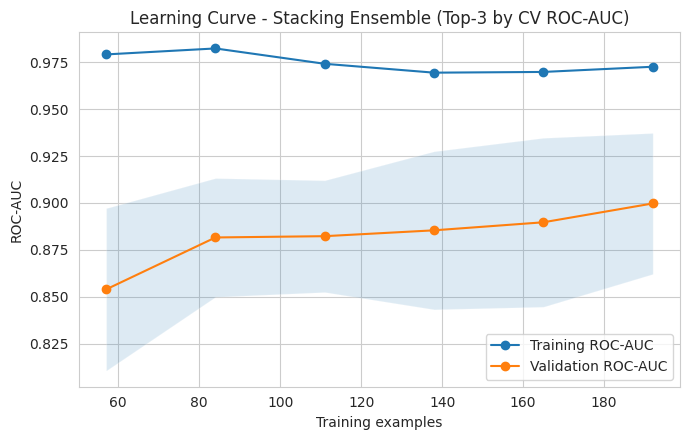

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    FINAL_MODEL, X_train, y_train, cv=cv, scoring='roc_auc',
    train_sizes=np.linspace(0.3, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE
)

plt.figure(figsize=(7, 4.5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training ROC-AUC')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation ROC-AUC')
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                  val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel('Training examples'); plt.ylabel('ROC-AUC')
plt.title(f'Learning Curve - {FINAL_NAME}')
plt.legend(); plt.tight_layout(); plt.show()


## 9. Novelty #2 - Explainable AI

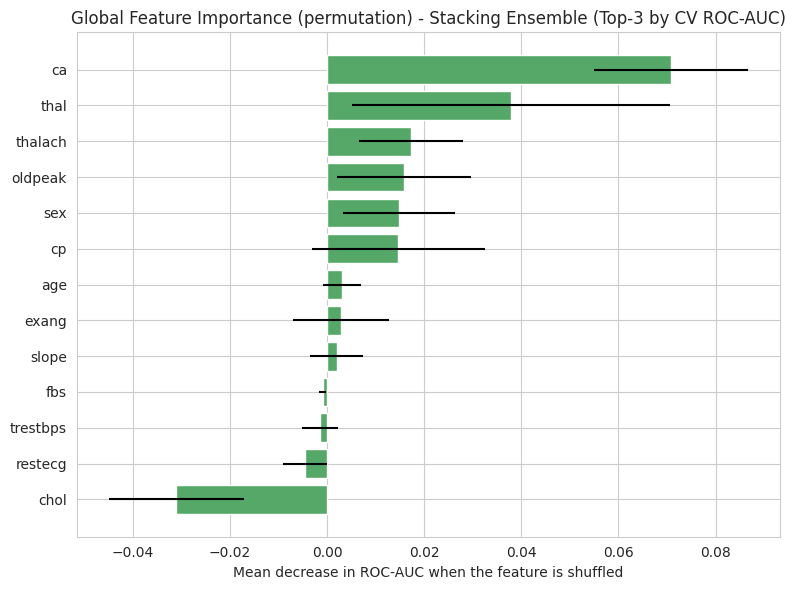

In [13]:
perm = permutation_importance(FINAL_MODEL, X_test, y_test, n_repeats=30,
                               random_state=RANDOM_STATE, scoring='roc_auc')
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std,
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'],
         xerr=importance_df['std'], color='#55A868')
plt.xlabel("Mean decrease in ROC-AUC when the feature is shuffled")
plt.title(f"Global Feature Importance (permutation) - {FINAL_NAME}")
plt.tight_layout()
plt.show()


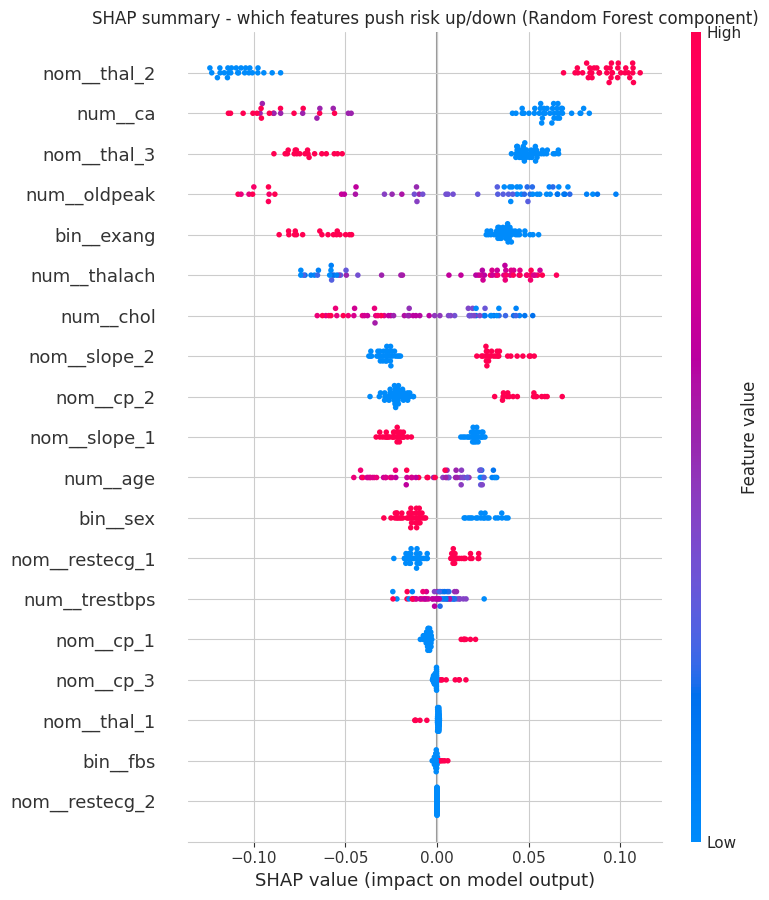

In [14]:
import shap

# Fast, exact local explanations from the tuned Random Forest component
rf_pipeline = best_estimators["Random Forest"]
rf_model = rf_pipeline.named_steps['clf']
rf_preprocess = rf_pipeline.named_steps['prep']
feature_names_out = rf_preprocess.get_feature_names_out()

X_test_transformed = rf_preprocess.transform(X_test)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_transformed)

# shap_values can be (n_samples, n_features, n_classes) or a list of arrays depending on
# the SHAP version - normalise to a single (n_samples, n_features) array for the positive class
if isinstance(shap_values, list):
    shap_pos = shap_values[1]
elif np.ndim(shap_values) == 3:
    shap_pos = shap_values[:, :, 1]
else:
    shap_pos = shap_values

plt.figure()
shap.summary_plot(shap_pos, X_test_transformed, feature_names=feature_names_out, show=False)
plt.title("SHAP summary - which features push risk up/down (Random Forest component)")
plt.tight_layout()
plt.show()


## 10. Save the Deployable Pipeline

In [15]:
import joblib

joblib.dump(FINAL_MODEL, 'cardioguard_pipeline.pkl')
joblib.dump({'rf_model': rf_model, 'rf_preprocess': rf_preprocess, 'feature_names_out': list(feature_names_out)},
            'cardioguard_explainer.pkl')
print("Saved cardioguard_pipeline.pkl (predictor) and cardioguard_explainer.pkl (SHAP explainer assets).")


Saved cardioguard_pipeline.pkl (predictor) and cardioguard_explainer.pkl (SHAP explainer assets).


## 11. User Interface - Interactive Clinical Risk Dashboard

In [16]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML

int_ranges = {
    'age':      dict(min=20, max=90,  step=1, value=int(X['age'].median()),      desc='Age'),
    'trestbps': dict(min=80, max=200, step=1, value=int(X['trestbps'].median()), desc='Resting BP'),
    'chol':     dict(min=100, max=600, step=1, value=int(X['chol'].median()),    desc='Cholesterol'),
    'thalach':  dict(min=60, max=210, step=1, value=int(X['thalach'].median()),  desc='Max Heart Rate'),
}
float_ranges = {
    'oldpeak': dict(min=0.0, max=6.5, step=0.1, value=float(X['oldpeak'].median()), desc='ST Depression'),
}

sex_w     = widgets.Dropdown(options=[('Female', 0), ('Male', 1)], value=1, description='Sex')
# cp / restecg / slope / thal codes are category-coded but not consistently documented across
# published mirrors of this dataset (see the data-quality note in Section 3) - shown as neutral
# categories here rather than asserting a specific clinical label for each numeric code.
cp_w      = widgets.Dropdown(options=[('cp = 0', 0), ('cp = 1', 1), ('cp = 2', 2), ('cp = 3', 3)],
                              value=0, description='Chest pain code')
fbs_w     = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=0, description='Fasting sugar>120')
restecg_w = widgets.Dropdown(options=[('restecg = 0', 0), ('restecg = 1', 1), ('restecg = 2', 2)],
                              value=0, description='Resting ECG code')
exang_w   = widgets.Dropdown(options=[('No', 0), ('Yes', 1)], value=0, description='Exercise angina')
slope_w   = widgets.Dropdown(options=[('slope = 0', 0), ('slope = 1', 1), ('slope = 2', 2)],
                              value=1, description='ST slope code')
ca_w      = widgets.Dropdown(options=[(str(i), i) for i in range(4)], value=0, description='Major vessels')
thal_w    = widgets.Dropdown(options=[('thal = 1', 1), ('thal = 2', 2), ('thal = 3', 3)],
                              value=2, description='Thalassemia code')

sliders = {}
for k, v in int_ranges.items():
    sliders[k] = widgets.IntSlider(min=v['min'], max=v['max'], step=v['step'], value=v['value'], description=v['desc'])
for k, v in float_ranges.items():
    sliders[k] = widgets.FloatSlider(min=v['min'], max=v['max'], step=v['step'], value=v['value'], description=v['desc'])

predict_btn = widgets.Button(description="Predict Risk", button_style='danger', icon='heartbeat')
output_area = widgets.Output()

def build_patient_df():
    row = {
        'age': sliders['age'].value, 'sex': sex_w.value, 'cp': cp_w.value,
        'trestbps': sliders['trestbps'].value, 'chol': sliders['chol'].value, 'fbs': fbs_w.value,
        'restecg': restecg_w.value, 'thalach': sliders['thalach'].value, 'exang': exang_w.value,
        'oldpeak': sliders['oldpeak'].value, 'slope': slope_w.value, 'ca': ca_w.value, 'thal': thal_w.value,
    }
    return pd.DataFrame([row])[X.columns]

def explain_patient(patient_df, top_k=4):
    # Return the top_k SHAP-driven risk factors (pushing risk up or down) for one
    # patient, using the fast tree explainer trained in Section 9.
    transformed = rf_preprocess.transform(patient_df)
    sv = explainer.shap_values(transformed)
    if isinstance(sv, list):
        sv = sv[1]
    elif np.ndim(sv) == 3:
        sv = sv[:, :, 1]
    contributions = pd.Series(sv[0], index=feature_names_out).sort_values(key=np.abs, ascending=False)
    return contributions.head(top_k)

def on_predict_click(_):
    with output_area:
        clear_output()
        patient = build_patient_df()
        risk_prob = FINAL_MODEL.predict_proba(patient)[0, 1]
        label = "HIGH RISK" if risk_prob >= 0.5 else "LOW RISK"
        color = "#C44E52" if risk_prob >= 0.5 else "#55A868"

        display(HTML(f'''
        <div style="padding:14px;border-radius:10px;background:{color}22;border:2px solid {color}">
        <h3 style="margin:0;color:{color}">{label} - predicted probability: {risk_prob:.1%}</h3>
        </div>
        '''))

        top_factors = explain_patient(patient)
        print("\nTop factors driving this prediction (SHAP, Random Forest component):")
        for feat, val in top_factors.items():
            direction = "pushes risk UP" if val > 0 else "pushes risk DOWN"
            print(f"  {feat:28s} {direction:16s} (SHAP = {val:+.3f})")

predict_btn.on_click(on_predict_click)

ui = widgets.VBox([
    widgets.HTML("<h4>Patient parameters</h4>"),
    widgets.HBox([sliders['age'], sex_w]),
    widgets.HBox([cp_w, restecg_w]),
    widgets.HBox([sliders['trestbps'], sliders['chol']]),
    widgets.HBox([sliders['thalach'], fbs_w]),
    widgets.HBox([exang_w, slope_w]),
    widgets.HBox([ca_w, thal_w]),
    sliders['oldpeak'],
    predict_btn,
    output_area,
])
display(ui)


### 11b. Automated Sanity Test

In [ ]:
majority_baseline = max(y_test.mean(), 1 - y_test.mean())
model_accuracy = accuracy_score(y_test, y_pred_stack)
print(f"Majority-class baseline accuracy: {majority_baseline:.3f}")
print(f"Model test accuracy:              {model_accuracy:.3f}")
assert model_accuracy > majority_baseline, "Model should beat the naive majority-class baseline"

correct_mask = (y_pred_stack == y_test.values)
negative_idx = y_test[(y_test == 0) & correct_mask].index[0]
positive_idx = y_test[(y_test == 1) & correct_mask].index[0]
negative_patient = X_test.loc[[negative_idx]]
positive_patient = X_test.loc[[positive_idx]]

neg_prob = FINAL_MODEL.predict_proba(negative_patient)[0, 1]
pos_prob = FINAL_MODEL.predict_proba(positive_patient)[0, 1]
print(f"\nReal patient, true label = No Disease -> predicted risk = {neg_prob:.1%}")
print(f"Real patient, true label = Disease    -> predicted risk = {pos_prob:.1%}")
assert pos_prob > neg_prob, "Model should assign higher predicted risk to the confirmed-disease patient"
assert neg_prob < 0.5, "Model should classify the confirmed-negative patient as low risk"
assert pos_prob >= 0.5, "Model should classify the confirmed-positive patient as high risk"
print("\nSanity checks passed on real held-out patients: predictions are data-driven, not random.")


Majority-class baseline accuracy: 0.541
Model test accuracy:              0.770

Real patient, true label = No Disease -> predicted risk = 9.6%
Real patient, true label = Disease    -> predicted risk = 91.3%

Sanity checks passed on real held-out patients: predictions are data-driven, not random.
